In [60]:
# ============================================================
# CELDA 1 · Cargar modelo, preprocessor y datos
# ============================================================

import numpy as np
import pandas as pd
# Shap (Shapley Additive exPlanations) nos informa de cuánto contribuyó cada variable a 
# empujar la predicción hacia Churn o No Churn para cada predicción individual.
# Shap es una librería para realizar inteligencia artificial explicable (Wikipedia, 11/03/2026)
import shap
import joblib
import matplotlib.pyplot as plt
import matplotlib
import os
import warnings
warnings.filterwarnings('ignore')

# ── Cargar el modelo y el preprocessor ──────────────────────
# El modelo ganador del Día 4
modelo = joblib.load('../models/best_model.pkl')

# El pipeline de preprocesamiento del Día 3
preprocessor = joblib.load('../models/preprocessor.pkl')

# ── Cargar los datos procesados ──────────────────────────────
X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')


# ── Obtener los nombres de las columnas tras el OneHotEncoding
# El preprocessor sabe qué columnas generó — se los pedimos directamente
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace('num__', '').replace('cat__', '')
                 for name in feature_names]

print(f"Modelo cargado: {type(modelo).__name__}")
print(f"X_test shape: {X_test.shape}")
print(f"Número de features: {len(feature_names)}")
print(f"\nNombre de las features:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")


Modelo cargado: LogisticRegression
X_test shape: (1409, 45)
Número de features: 45

Nombre de las features:
   1. tenure
   2. MonthlyCharges
   3. gender_Female
   4. gender_Male
   5. SeniorCitizen_0
   6. SeniorCitizen_1
   7. Partner_No
   8. Partner_Yes
   9. Dependents_No
  10. Dependents_Yes
  11. PhoneService_No
  12. PhoneService_Yes
  13. MultipleLines_No
  14. MultipleLines_No phone service
  15. MultipleLines_Yes
  16. InternetService_DSL
  17. InternetService_Fiber optic
  18. InternetService_No
  19. OnlineSecurity_No
  20. OnlineSecurity_No internet service
  21. OnlineSecurity_Yes
  22. OnlineBackup_No
  23. OnlineBackup_No internet service
  24. OnlineBackup_Yes
  25. DeviceProtection_No
  26. DeviceProtection_No internet service
  27. DeviceProtection_Yes
  28. TechSupport_No
  29. TechSupport_No internet service
  30. TechSupport_Yes
  31. StreamingTV_No
  32. StreamingTV_No internet service
  33. StreamingTV_Yes
  34. StreamingMovies_No
  35. StreamingMovies_No inte

*Las 3 primeras son las features numéricas, el resto se corresponden con las features categóricas expandidas por OneHotEncoder*

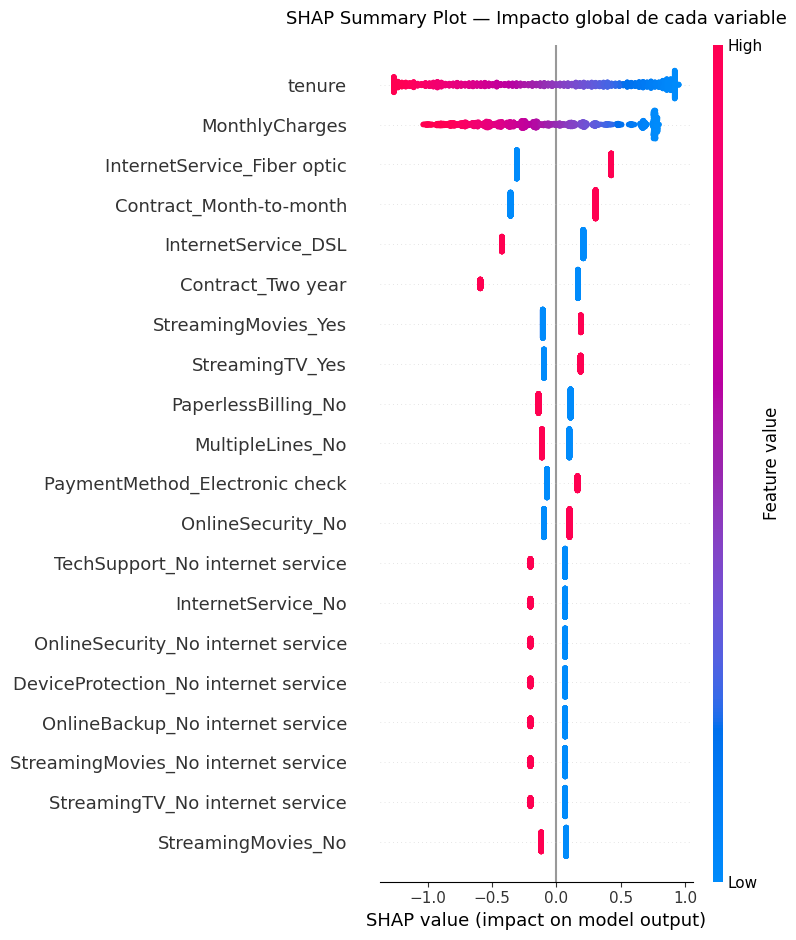

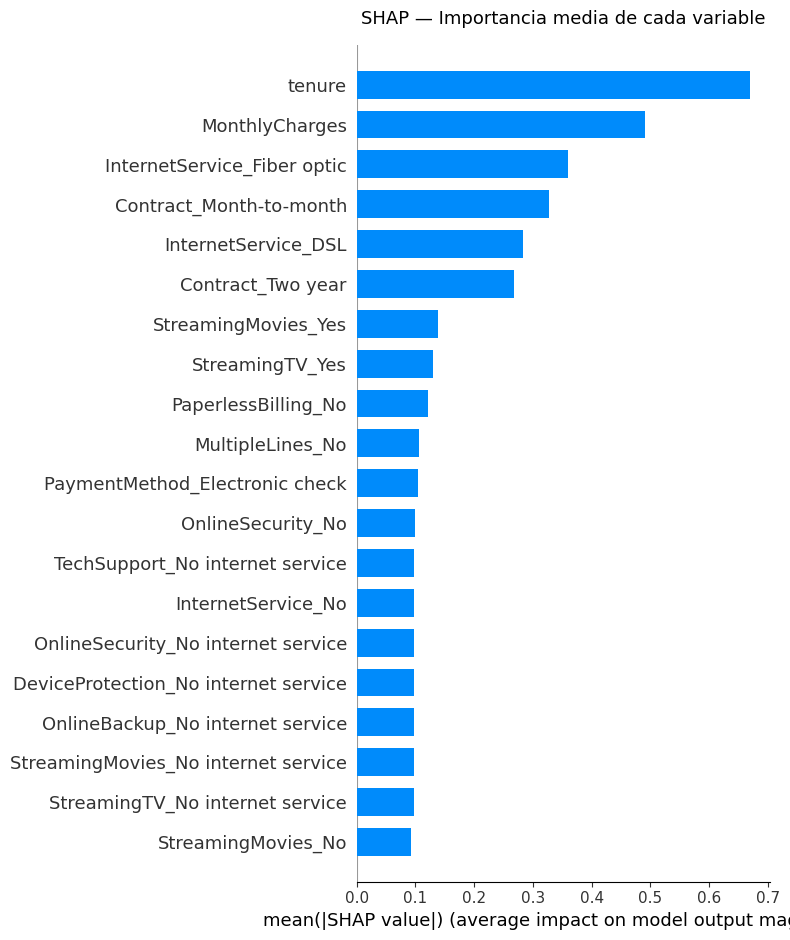


🔝 Top 10 features por importancia SHAP:
---------------------------------------------
   1. tenure                          |SHAP| medio = 0.6700
   2. MonthlyCharges                  |SHAP| medio = 0.4900
   3. InternetService_Fiber optic     |SHAP| medio = 0.3591
   4. Contract_Month-to-month         |SHAP| medio = 0.3279
   5. InternetService_DSL             |SHAP| medio = 0.2825
   6. Contract_Two year               |SHAP| medio = 0.2680
   7. StreamingMovies_Yes             |SHAP| medio = 0.1375
   8. StreamingTV_Yes                 |SHAP| medio = 0.1300
   9. PaperlessBilling_No             |SHAP| medio = 0.1218
  10. MultipleLines_No                |SHAP| medio = 0.1064


In [61]:
# ============================================================
# CELDA 2 · SHAP — Análisis global (Summary Plot)
# ============================================================
# LinearExplainer es el explicador optimizado para modelos lineales
# (LogisticRegression, Ridge, Lasso, SVM lineal, etc.)
# TreeExplainer es solo para árboles (XGBoost, RandomForest, LightGBM).
explainer = shap.LinearExplainer(modelo, X_test)

# Calculamos los valores SHAP para todos los clientes del test set
# Cada valor SHAP dice: "esta feature empujó la predicción X puntos
# hacia Churn (+) o hacia No Churn (-) para este cliente concreto"
shap_values = explainer.shap_values(X_test)

# ── Summary Plot (Bee Swarm) ────────────────────────────────
# Cada punto = 1 cliente. Eje X = impacto en la predicción.
# Color rojo = valor alto de esa feature, azul = valor bajo.
# Las features se ordenan de más a menos importante.
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot — Impacto global de cada variable", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/SHAP_Summary_Plot.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# ── Bar Plot (importancia media) ────────────────────────────
# Versión simplificada: solo barras con la importancia media absoluta.
# Útil para presentaciones donde el bee swarm puede confundir.
shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title("SHAP — Importancia media de cada variable", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/SHAP_Importancia_media_cada_variable.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top 10 features (para copiar y pedir interpretación de negocio) ──
mean_shap = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(mean_shap)[::-1][:10]
print("\n🔝 Top 10 features por importancia SHAP:")
print("-" * 45)
for rank, idx in enumerate(top10_idx, 1):
    print(f"  {rank:2d}. {feature_names[idx]:<30s}  |SHAP| medio = {mean_shap[idx]:.4f}")

*Cómo interpretar SHAP Summary Plot (se comentan las cinco primeras variables):*
- *tenure es la barra más larga, así que es la característica con mayor importancia global. Los puntos azules* *(clientes con tenure bajo, recién llegados) se acumulan a la derecha (hacia Churn). Los puntos rojos (clientes* *con mucha antigüedad) se acumulan a la izquierda (hacia No Churn).*
- *MonthlyCharges es la siguiente barra en tamaño. Los clientes con cuota baja se acumulan hacia la derecha* *(hacia Churn).*
- *InternetService_Fiber optic es el tercer predictor. Los puntos rojos (Fiber optic=1) están claramente a la* *derecha, así que tener Fibra Óptica empuja hacia Churn.*
- *Contract_Month-to-month está en cuarto lugar y muestra que los que tienen un contrato mes a mes están más* *cerca de irse.*
- *InternetService_DSL en el siguiente puesto nos indica que los que no tienen este servicio están posicionados* *hacia Churn tímidamente.*
- *Contract_Two year muestra que si se tiene este tipo de contrato se tienen muchas más posibilidades de quedarse* *que si no se tiene.*
- *El resto de variables como se puede corroborar con el BoxPlot tienen menos importancia a la hora de predecir.* 

Cliente #9 — Churn real: Sí
Probabilidad predicha de Churn: 64.3%



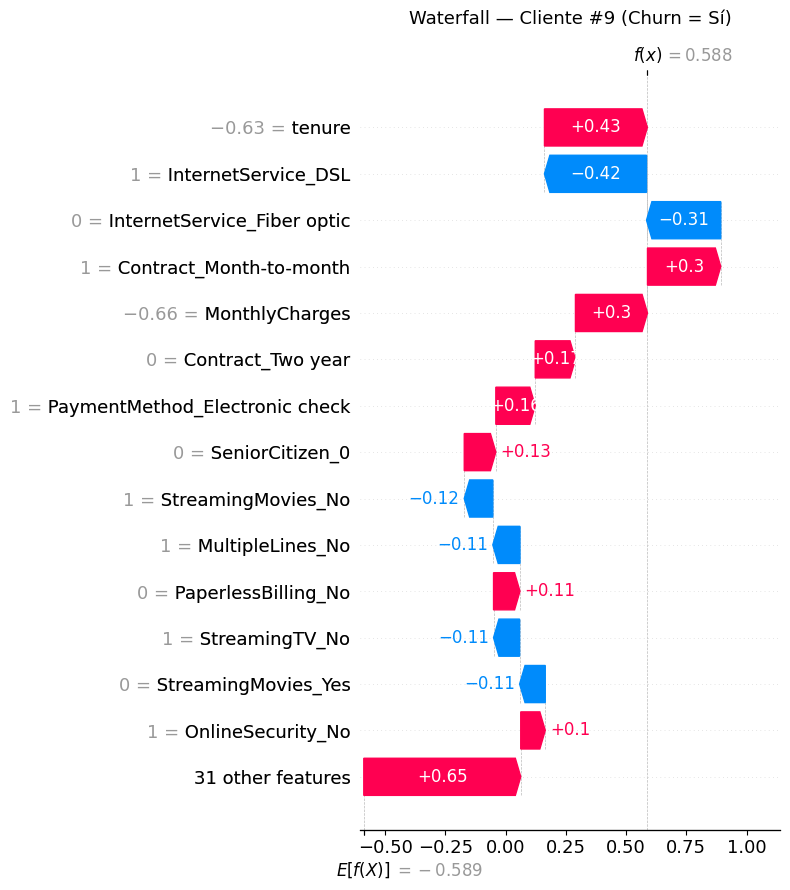


Cliente #0 — Churn real: No
Probabilidad predicha de Churn: 8.8%



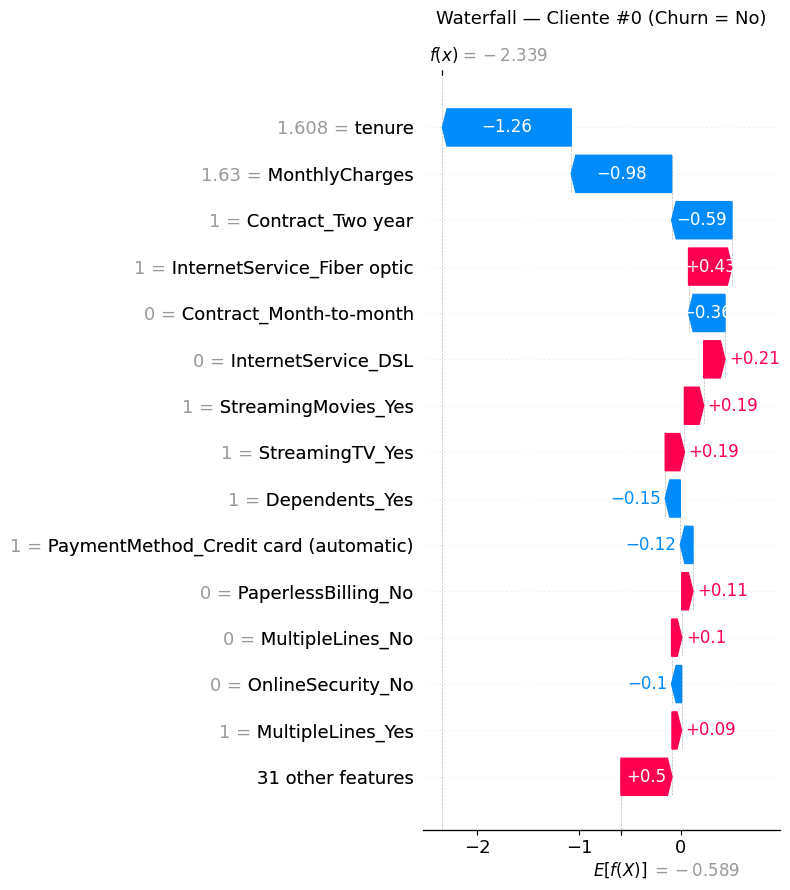

In [62]:
# ============================================================
# CELDA 3 · SHAP — Waterfall Plot (cliente individual)
# ============================================================
# El waterfall muestra cómo SE CONSTRUYE la predicción de UN solo cliente:
# empieza en el valor base (predicción promedio) y cada feature lo empuja
# hacia arriba (Churn) o hacia abajo (No Churn).

# LinearExplainer devuelve un array numpy, pero waterfall_plot necesita
# un objeto Explanation. Lo construimos manualmente:
base_value = explainer.expected_value  # predicción promedio del modelo

# ── Cliente que SÍ hizo churn ───────────────────────────────
idx_churn = np.where(y_test == 1)[0][0]
print(f"Cliente #{idx_churn} — Churn real: Sí")
print(f"Probabilidad predicha de Churn: {modelo.predict_proba(X_test[idx_churn:idx_churn+1])[0][1]:.1%}\n")

# Creamos el objeto Explanation que waterfall_plot necesita
explanation_churn = shap.Explanation(
    values=shap_values[idx_churn],       # valores SHAP de este cliente
    base_values=base_value,               # valor base (promedio)
    data=X_test[idx_churn],               # valores reales de las features
    feature_names=feature_names           # nombres legibles
)

shap.waterfall_plot(explanation_churn, max_display=15, show=False)
plt.title(f"Waterfall — Cliente #{idx_churn} (Churn = Sí)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/SHAP_waterfall_SI_churn.png.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# ── Cliente que NO hizo churn (para comparar) ───────────────
idx_no_churn = np.where(y_test == 0)[0][0]
print(f"\nCliente #{idx_no_churn} — Churn real: No")
print(f"Probabilidad predicha de Churn: {modelo.predict_proba(X_test[idx_no_churn:idx_no_churn+1])[0][1]:.1%}\n")

explanation_no_churn = shap.Explanation(
    values=shap_values[idx_no_churn],
    base_values=base_value,
    data=X_test[idx_no_churn],
    feature_names=feature_names
)

shap.waterfall_plot(explanation_no_churn, max_display=15, show=False)
plt.title(f"Waterfall — Cliente #{idx_no_churn} (Churn = No)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/SHAP_waterfall_NO_churn.png.png', 
            dpi=150, bbox_inches='tight')
plt.show()

*Interpretación de Waterfall-No Churn:*  
*Este cliente no se fue y los motivos principales detectados para no irse* *han sido: antigüedad alta, cargos mensuales altos, contrato de 2 años y contar con personas dependientes en el contrato. Aunque tener fibra óptica empuja hacia* *churn, no es suficiente.*  

*Interpretación de Waterfall-Churn:*  
*Este cliente se fue y los motivos principales fueron: antigüedad baja, contrato mes a mes o no tener un contrato* *de 2 años, cargo mensual bajo y pago con cheque electrónico.* 

# CONCLUSIONES #

Si la empresa solo puede actuar sobre 2 palancas debe centrarse en la antigüedad del cliente y en lo que paga al mes. El perfil de riesgo es cliente nuevo, con fibra, contrato mensual y factura alta. El perfil más seguro es lo opuesto: cliente veterano con contrato largo. Un cliente antiguo con contrato largo es muy estable aunque pague mucho. Un cliente nuevo sin contrato fijo y que paga con cheque electrónico es el perfil clásico de abandono.   

**¿Qué acciones podría tomar la empresa?**:  

- Incentivar contratos largos en los primeros meses con un descuento.
- Revisar el pricing de fibra óptica.
- Migrar pagos de cheque electrónico a automáticos.